In [1]:
import torch # for step 3
from torchvision import datasets, transforms # for step 3
from torch.utils.data import DataLoader # for step 3
import torch.nn as nn # for step 4
#import torchvision.models as models # for step 4, this line is generating errors
from torchvision.models import resnet18, ResNet18_Weights
import torch.optim as optim # for step 5
from sklearn.metrics import accuracy_score, confusion_matrix # step 6
from PIL import Image
import torch.nn.functional as F
import torchvision



# A Function to convert transpartent images to 3-dimensional tensor 'RGB' format
def pil_loader(path):
    with open(path, 'rb') as f:
        img = Image.open(f)
        return img.convert("RGB")   # force conversion, no transparency warning



# Define transforms for the RGB format (resize, normalize, augment)
transform = transforms.Compose([
    transforms.Resize((128, 128)),   # resize logos
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                        std=[0.5, 0.5, 0.5])
])



# Load dataset locations on the personal device
train_dataset = datasets.ImageFolder(
    root="C:/Users/17135/Code For School/EE_3326/Project/data/train",transform=transform,loader=pil_loader)

val_dataset = datasets.ImageFolder(
    root="C:/Users/17135/Code For School/EE_3326/Project/data/val",transform=transform,loader=pil_loader)



# Create loaders pointing to the dataset locations
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)



#print(f"Classes: {train_dataset.classes}") # redundant info not needing to be pushed



# Step 4: Defining a multi-class classification, & multi-model initillization and configuration



# model = resnet18(weights=ResNet18_Weights.DEFAULT) # the new line to stop generating warning messages
# ^ A way to hardcode the model, rather than giving interchangable options



class DetectorBase:
    def forward(self, x):
        raise NotImplementedError

class ResNetDetector(DetectorBase):
    def __init__(self):
        self.model = torchvision.models.resnet18(weights=ResNet18_Weights.DEFAULT)
    def forward(self, x):
        return self.model(x)

class CustomCNNDetector(DetectorBase):
    def __init__(self):
        self.model = MyCNN()
    def forward(self, x):
        return self.model(x)

class MyCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(MyCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 32 * 32, 128)  # adjust for your input size
        self.fc = nn.Linear(128, num_classes)    # final classifier, named 'fc'

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc(x)   # use 'fc' here
        return x

class CustomCNNDetector(DetectorBase):
    def __init__(self):
        self.model = MyCNN(num_classes=10)  # adjust num_classes to your dataset
    def forward(self, x):
        return self.model(x)



# User choice of which detector to use
choice = input("What model would you like to use? ResNet Detector or Custom CNN Detector? Type 'ResNet' or 'CNN' Specifically. Otherwise, the option is nullified.")
if choice == 'ResNet': 
    detector = ResNetDetector()
elif choice == 'CNN':
    detector = CustomCNNDetector()
else:
    detector = None
    print("Invalid choice. Detector option is nullified.")



# Access the underlying model if needed
model = detector.model



# Specify the maximum number of classes that can be processed
model.fc = nn.Linear(model.fc.in_features, 2000) # this 200 value is the max amount of folders, or classes, that can be analyzed



 # Step 5: Training loop
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)



for epoch in range(10):  # adjust epochs, the higher will provide higher quality analysis
    model.train()
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = detector.forward(images) # model(images) # was model(images) before adding CNN interchangability
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} complete")



 # step 6: Evaluation
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        outputs = detector.forward(images) # 'output = model(images)' before adding CNN interchangability
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())



#print("Accuracy:", accuracy_score(all_labels, all_preds))
#print("Confusion Matrix:\n", confusion_matrix(all_labels, all_preds))
print("Done!! Pleast check your results...")



 # step 7 - save the model that can be imported for further utilization
torch.jit.script(model).save("logo_classifier.pt")




What model would you like to use? ResNet Detector or Custom CNN Detector? Type 'ResNet' or 'CNN' Specifically. Otherwise, the option is nullified. CNN


Epoch 1 complete
Epoch 2 complete
Epoch 3 complete
Epoch 4 complete
Epoch 5 complete
Epoch 6 complete
Epoch 7 complete
Epoch 8 complete
Epoch 9 complete
Epoch 10 complete
Done!! Pleast check your results...


 # Post import checks

In [2]:
print("Accuracy:", accuracy_score(all_labels, all_preds))
# print("Confusion Matrix:\n", confusion_matrix(all_labels, all_preds)) # redundant testing of printing of the confusion matrix

Accuracy: 0.9894625922023182


In [3]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

print("Confusion Matrix:")
for row in cm:
    print(row)

Confusion Matrix:
[58  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0]
[ 0 79  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0]
[ 0  0 88  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0]
[ 0  0  0 76  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0]
[ 0  0  0  0 55  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0 

 # Run this after initial import test for "customer" utilization

 # 1. Load the scripted model made in step 7 of the first script

In [4]:
import torch

model = torch.jit.load("logo_classifier.pt") # what was saved in the previous step
model.eval()

RecursiveScriptModule(
  original_name=MyCNN
  (conv1): RecursiveScriptModule(original_name=Conv2d)
  (conv2): RecursiveScriptModule(original_name=Conv2d)
  (pool): RecursiveScriptModule(original_name=MaxPool2d)
  (fc1): RecursiveScriptModule(original_name=Linear)
  (fc): RecursiveScriptModule(original_name=Linear)
)

 # 2. Apply the same transforms you used for training, run Ad Hoc image analysis

In [5]:
import os
from PIL import Image
import torch
from torchvision import transforms


transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])


# Load all spontaneous image comparisons into one folder

img_dir = "C:/Users/17135/Code For School/EE_3326/Project/data/test_images/"

# Begin creating 

images = []
filenames = []
for fname in os.listdir(img_dir):
    if fname.lower().endswith((".jpg", ".png")):
        img = Image.open(os.path.join(img_dir, fname)).convert("RGB")
        img_tensor = transform(img).unsqueeze(0)  # add batch dimension
        images.append(img_tensor)
        filenames.append(fname)

# Stacking unlimited image comparison requests into one batch

batch = torch.cat(images)


# Running inference

model.eval()
with torch.no_grad():
    outputs = model(batch)
    _, preds = torch.max(outputs, 1)

for fname, pred in zip(filenames, preds):
    print(f"{fname} → {train_dataset.classes[pred.item()]}")


18.jpg → Cadillac
59.jpg → Aston Martin
test1.JPG → Nordstrom Rack
test2.jpg → Star Wars


 # 3. Map index back to class name for spontaneous images

In [8]:
classes = train_dataset.classes  # during training
for fname, pred in zip(filenames, preds):
    print("Predicted class:", classes[pred.item()])

Predicted class: Cadillac
Predicted class: Aston Martin
Predicted class: Nordstrom Rack
Predicted class: Star Wars


 # - Per‑class metrics

In [9]:
from sklearn.metrics import classification_report
import numpy as np

# Full set of class indices
labels = list(range(len(train_dataset.classes)))  # 0..100

print(classification_report(
    all_labels,
    all_preds,
    labels=labels,                     # force all 101 classes
    target_names=train_dataset.classes,
    zero_division=0                    # avoid warnings for empty classes
))

                    precision    recall  f1-score   support

              AND1       0.98      1.00      0.99        58
   Alaska Airlines       0.99      1.00      0.99        79
 American Airlines       0.99      1.00      0.99        88
      Aston Martin       1.00      1.00      1.00        76
              Asus       1.00      1.00      1.00        55
              Audi       1.00      0.99      0.99        83
               BAE       1.00      1.00      1.00        55
     BANK OF CHINA       1.00      1.00      1.00        52
          Cadillac       1.00      1.00      1.00        69
        California       1.00      1.00      1.00        79
         Chevrolet       1.00      0.97      0.99        69
           Chevron       1.00      1.00      1.00        81
           Colgate       1.00      0.99      0.99        69
          Columbia       1.00      0.91      0.95        91
    Dollar General       1.00      0.99      0.99        68
       Dollar Tree       0.97      1.00

 # - Confusion matrix heatmap


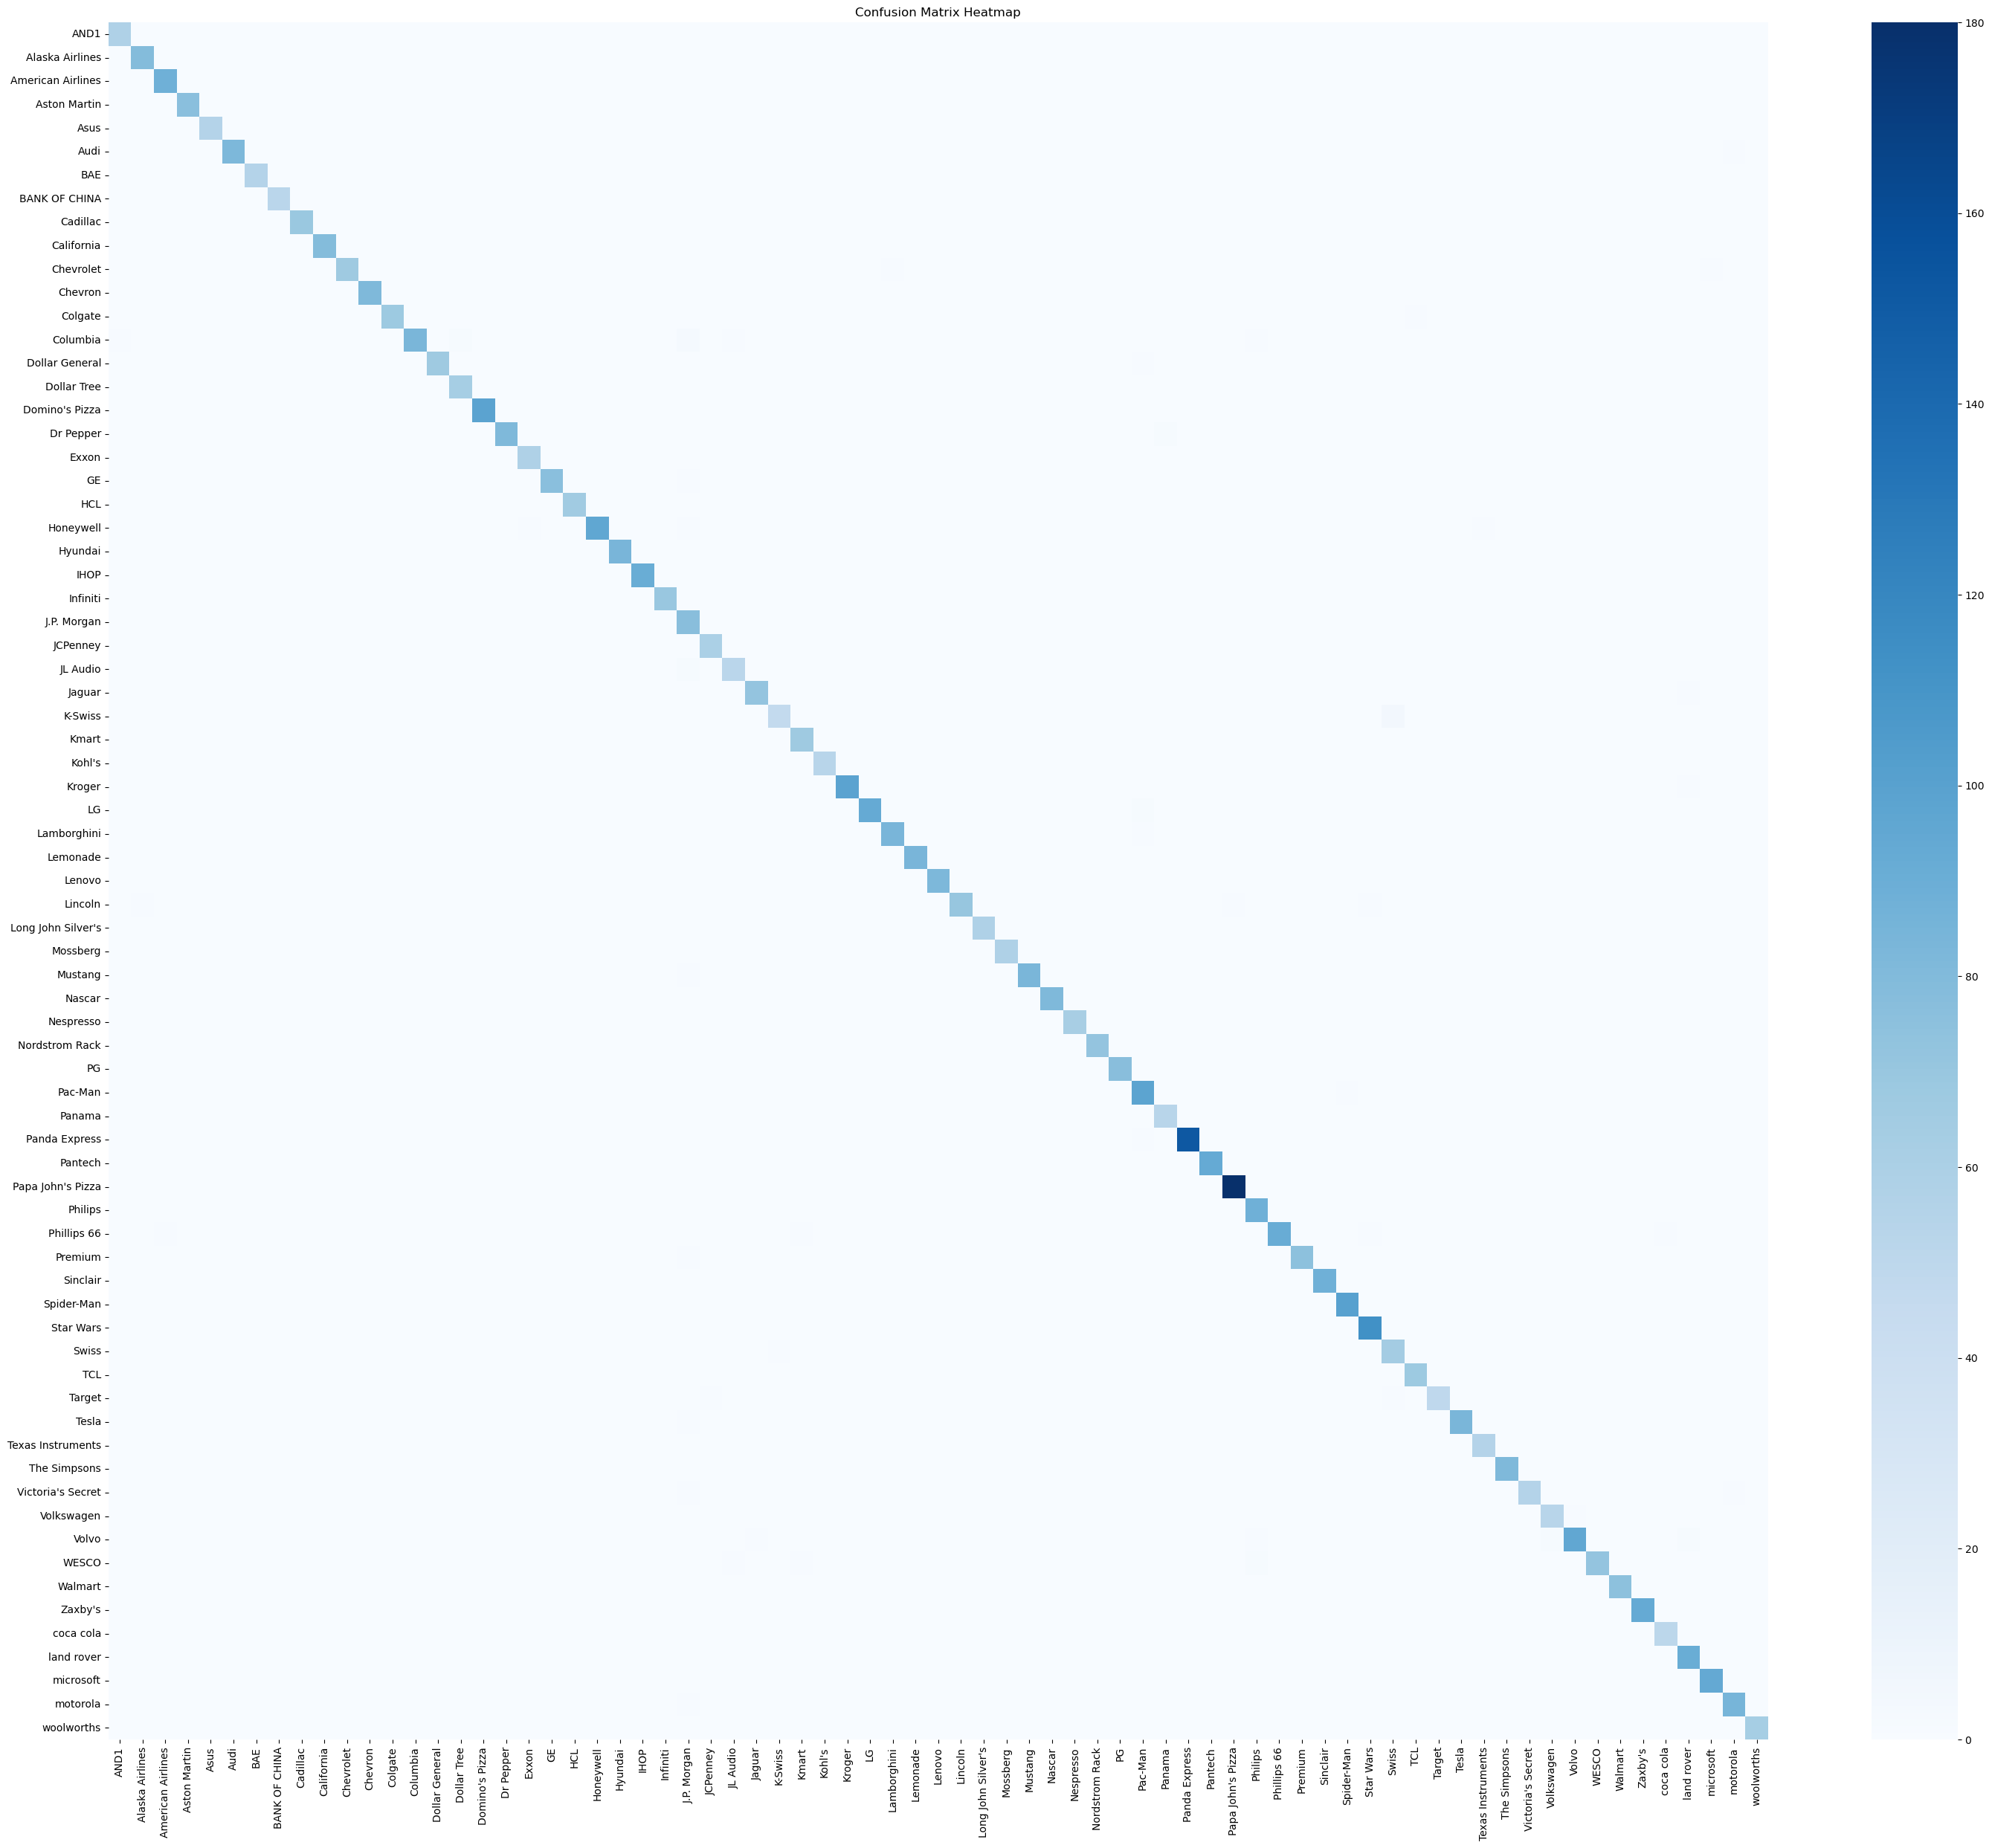

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(36,30))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)
plt.title("Confusion Matrix Heatmap")
plt.show()